# A second RL line for LDM, on SkyRL

The small-molecule acquisition RL line has one number it exists to produce:
Pareto hypervolume at budget 80, on G12D and on G12C, for SFT+RL against
SFT-only. That number does not exist yet. What stands between the line and it is
not the evaluation stack but the training: across seven 9B runs with
checkpoints, every one of 238 recorded gradient norms was non-finite, and 37 of
269 optimizer steps took effect.

This is a plan to stand a second training line beside the existing one, built on
[SkyRL](https://github.com/NovaSky-AI/SkyRL) and shaped by
[ApexAgents-SkyRL-Recipe](https://github.com/Mercor-Intelligence/ApexAgents-SkyRL-Recipe),
which trains knowledge-work agents up to 397B on released SkyRL with no forks.
slime keeps running. The two lines are judged against each other on the same
number, through the same evaluation stack.

Everything below is generated by
[`skyrl_port_plan.ipynb`](rl/ldm_skyrl/skyrl_port_plan.ipynb), which reads
frozen JSON committed alongside it rather than recomputing or calling the
network, so this text and the notebook cannot drift apart.

In [1]:
import json
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from PIL import Image as PILImage

plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 7.5,
    "axes.grid": True, "grid.alpha": .22, "grid.linewidth": .5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 8.5, "axes.labelsize": 7.5,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
})

INK, HL, CTRL, WARN, MUTE = "#22303f", "#c1442e", "#5b7c99", "#d99b28", "#9aa7b1"

HERE = Path.cwd()
FACTS = json.loads((HERE / "facts.json").read_text())
PHASES = json.loads((HERE / "phases.json").read_text())
PA = json.loads((HERE / "phase_a_results.json").read_text())
FIGDIR = HERE / "figs"; FIGDIR.mkdir(exist_ok=True)

def show(fig, name):
    """Save at 300 dpi, quantise to a 256-colour palette, display inline.

    The quantise step happens here rather than as a post-process on the .ipynb
    because `nbconvert --execute --inplace` would re-run the cell and silently
    undo anything applied to the file afterwards.
    """
    p = FIGDIR / f"{name}.png"
    fig.savefig(p, bbox_inches="tight")
    plt.close(fig)
    im = PILImage.open(p).convert("RGB").quantize(colors=256, method=PILImage.MEDIANCUT)
    im.save(p, optimize=True)
    print(f"{name}.png  {p.stat().st_size/1024:.0f} KB")
    display(Image(filename=str(p)))

print(f"facts collected {FACTS['collected_utc']} | ldm_rl read at {FACTS['ldm_rl_ref'][:8]}")

facts collected 2026-09-08T22:59:21Z | ldm_rl read at 18fa414c


## 1. The port is one file wide

`rl/ldm_rl` was written against contracts rather than against slime: its own
module docstring says the environment "depends only on `ldm_tts` contracts,
never on Slime or a specific task". That claim is checkable, and it holds.

f1_port_surface.png  48 KB


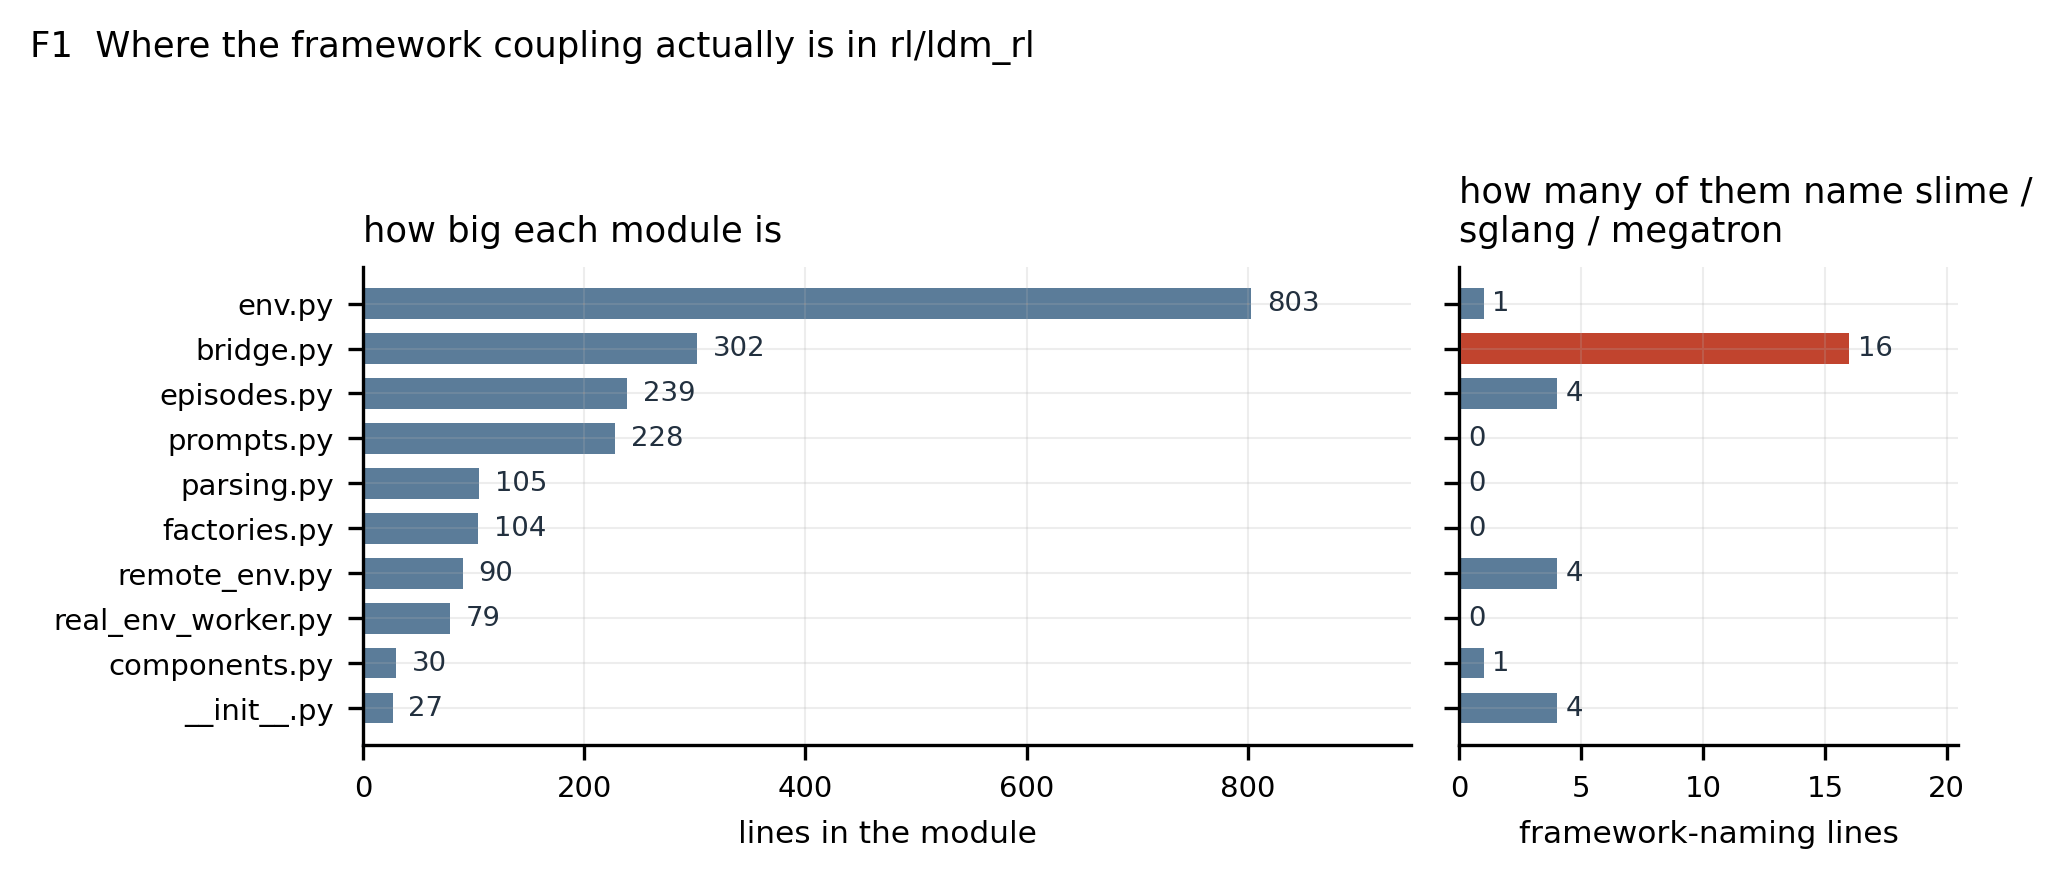

2007 lines total, 30 of them name a framework.
bridge.py: 302 lines carrying 16 of those 30.
env.py:    803 lines carrying 1.


In [2]:
ps = sorted(FACTS["port_surface"], key=lambda r: r["lines"])
names = [r["file"] for r in ps]
lines = [r["lines"] for r in ps]
coupled = [r["coupled_lines"] for r in ps]
y = np.arange(len(names))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.6, 2.9), sharey=True,
                             gridspec_kw={"width_ratios": [2.1, 1]})
a1.barh(y, lines, color=CTRL, height=.68, edgecolor="none")
for yi, ln in zip(y, lines):
    a1.text(ln + 14, yi, str(ln), va="center", fontsize=6.6, color=INK)
a1.set_xlim(0, max(lines) * 1.18)
a1.set_yticks(y); a1.set_yticklabels(names)
a1.set_xlabel("lines in the module")
a1.set_title("how big each module is", loc="left")

a2.barh(y, coupled, color=[HL if c >= 10 else (CTRL if c else MUTE) for c in coupled],
        height=.68, edgecolor="none")
for yi, c in zip(y, coupled):
    a2.text(c + .35, yi, str(c), va="center", fontsize=6.6, color=INK)
a2.set_xlim(0, max(coupled) * 1.28)
a2.set_xlabel("framework-naming lines")
a2.set_title("how many of them name slime /\nsglang / megatron", loc="left")

fig.suptitle("F1  Where the framework coupling actually is in rl/ldm_rl",
             x=0.005, ha="left", fontsize=8.5)
fig.tight_layout(rect=(0, 0, 1, .93))
show(fig, "f1_port_surface")

tot_l = sum(lines); tot_c = sum(coupled)
bridge = next(r for r in ps if r["file"] == "bridge.py")
env = next(r for r in ps if r["file"] == "env.py")
print(f"{tot_l} lines total, {tot_c} of them name a framework.")
print(f"bridge.py: {bridge['lines']} lines carrying {bridge['coupled_lines']} of those {tot_c}.")
print(f"env.py:    {env['lines']} lines carrying {env['coupled_lines']}.")

**F1.** The environment is 803 lines and names a framework on one of them; `bridge.py` carries 16 of the 30 coupled lines in the package, so replacing the framework means replacing one adapter rather than rewriting the loop.

## 2. Only one SkyRL version can run on this cluster

This is the constraint that decides the pin, and it is worth stating before
anything else, because it invalidates the obvious choice. SkyRL `main` requires
CUDA 13.0 and an r580 driver. This cluster runs driver 565, which is CUDA 12.7,
and the line already knows what a cu130 build does here: it installs, and then
`torch.cuda.is_available()` returns False.

The recipe pins SkyRL 0.3.0 at commit `b8a5caaa`, whose wheels are cu128 and
cu129. That is inside the red line.

f2_cuda_red_line.png  35 KB


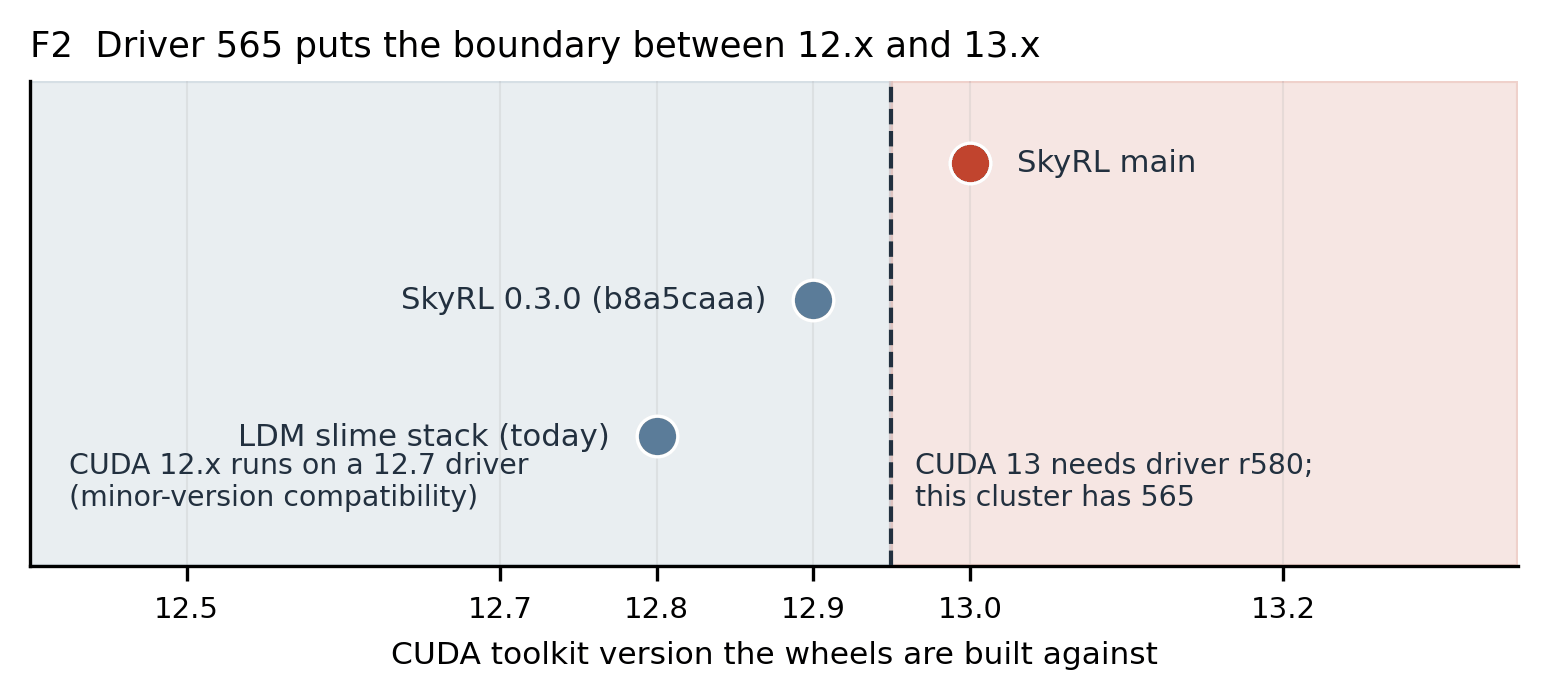

BLOCKED   SkyRL main   (needs CUDA 13.0, driver r580)
FEASIBLE  SkyRL 0.3.0 (b8a5caaa)   (needs CUDA 12.8 / 12.9, driver r525+ (minor-version compat))
FEASIBLE  LDM slime stack (today)   (needs CUDA 12.8 / 12.9, driver 565)


In [3]:
cc = FACTS["cuda_constraint"]
pts = [
    ("LDM slime stack (today)", 12.8, True),
    ("SkyRL 0.3.0 (b8a5caaa)", 12.9, True),
    ("SkyRL main", 13.0, False),
]
fig, ax = plt.subplots(figsize=(6.4, 2.1))
ax.axvspan(12.4, 12.95, color=CTRL, alpha=.13)
ax.axvspan(12.95, 13.35, color=HL, alpha=.13)
for k, (label, ver, ok) in enumerate(pts):
    ax.scatter([ver], [k], s=95, color=(CTRL if ok else HL), zorder=3,
               edgecolor="white", lw=.8)
    dx, ha = ((.03, "left") if not ok else (-.03, "right"))
    ax.text(ver + dx, k, label, ha=ha, va="center", fontsize=7.4, color=INK)
ax.axvline(12.95, color=INK, lw=1.0, ls="--")
ax.text(12.965, -.55, "CUDA 13 needs driver r580;\nthis cluster has 565",
        fontsize=6.8, color=INK, va="bottom")
ax.text(12.425, -.55, "CUDA 12.x runs on a 12.7 driver\n(minor-version compatibility)",
        fontsize=6.8, color=INK, va="bottom")
ax.set_yticks([]); ax.set_ylim(-.95, 2.6)
ax.set_xlim(12.4, 13.35); ax.set_xticks([12.5, 12.7, 12.8, 12.9, 13.0, 13.2])
ax.set_xlabel("CUDA toolkit version the wheels are built against")
ax.grid(axis="y", alpha=0)
ax.set_title(f"F2  Driver {cc['isambard_driver']} puts the boundary between 12.x and 13.x",
             loc="left")
show(fig, "f2_cuda_red_line")

for r in cc["rows"]:
    print(("FEASIBLE  " if r["feasible"] else "BLOCKED   ") + r["target"]
          + f"   (needs CUDA {r['needs_cuda']}, driver {r['needs_driver']})")

**F2.** The pin is not a preference: SkyRL 0.3.0 is the only version of the two that this driver can run at all.

SkyRL 0.3.0's inference backend is vLLM and nothing else
(`config.py:743`, `backend: str = \"vllm\"`), so the existing sglang deployment
does not carry over and the port depends on a vLLM aarch64 wheel existing at the
pinned version. It does.

In [4]:
v = FACTS["vllm_aarch64"]
print("index:", v["recipe_index"])
for w in v["wheels"]:
    print("  ", w)
print("\naarch64 wheel present on the pinned index:", v["aarch64_present"])
print("\nrecent vLLM releases on PyPI:")
for r in v["pypi_recent"]:
    print(f"   {r['version']:<8} aarch64={r['aarch64']}  x86_64={r['x86_64']}")

index: https://wheels.vllm.ai/0.23.0/cu129/vllm/
   vllm-0.23.0+cu129-cp38-abi3-manylinux_2_28_aarch64.whl
   vllm-0.23.0+cu129-cp38-abi3-manylinux_2_28_x86_64.whl

aarch64 wheel present on the pinned index: True

recent vLLM releases on PyPI:
   0.28.0   aarch64=True  x86_64=True
   0.27.1   aarch64=True  x86_64=True
   0.27.0   aarch64=True  x86_64=True
   0.26.0   aarch64=True  x86_64=True
   0.25.1   aarch64=True  x86_64=True
   0.25.0   aarch64=True  x86_64=True
   0.24.0   aarch64=True  x86_64=True
   0.23.0   aarch64=True  x86_64=True


The single largest technical risk in this port was whether SkyRL's only inference backend has a build for this architecture. It does, at the exact pinned version, on the exact index the recipe uses. That retires the risk at the wheel level only: whether it *runs* on driver 565 is phase item A2.

## 3. Two failures the slime line measured, and what SkyRL does about them

Two distinct non-finite-gradient stories on this line, which should not be run
together. The 1.5B one came from zero-variance groups turning `(r - mean) / std`
into `0/0`; its root cause was a prompt that showed a JSON Schema while asking
for an instance, and it is fixed. The 9B one is different: the gradients of
`linear_attn.A_log` and `dt_bias` are all non-finite while a later layer's are
finite, so the values are generated inside particular layers rather than
propagated back into them. Seven hypotheses have been excluded by measurement.

f3_zero_variance.png  48 KB


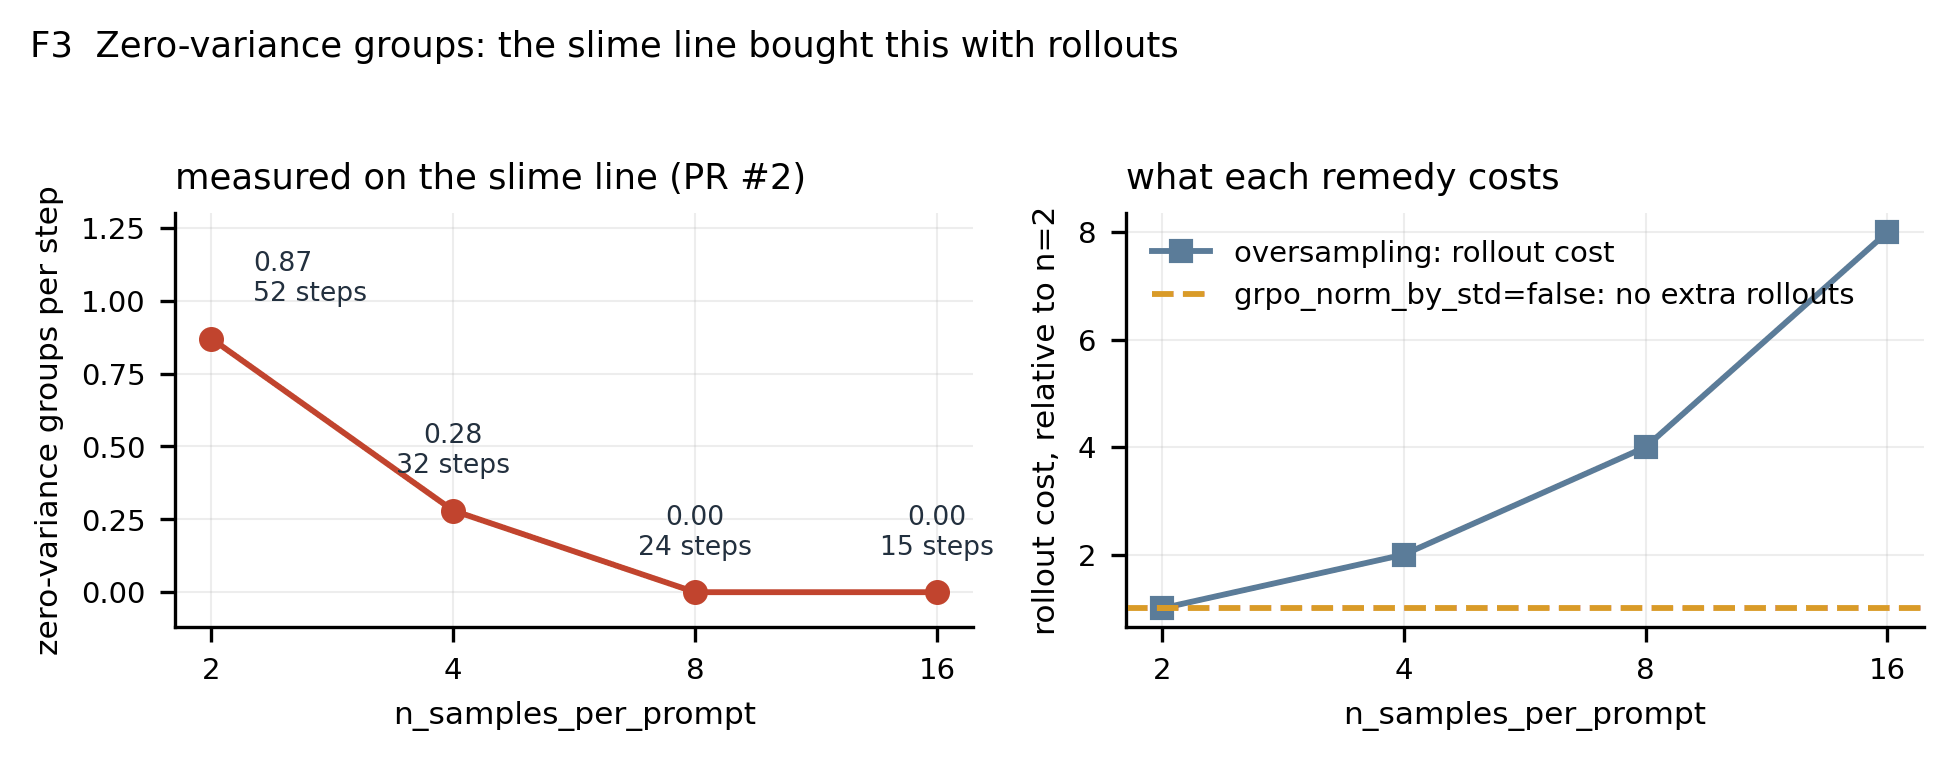

arm step counts are unequal: {2: 52, 4: 32, 8: 24, 16: 15}
the two 0.00 readings rest on 24 and 15 steps respectively, not on equal power.


In [5]:
zv = FACTS["zero_variance"]["rows"]
n = [r["n_samples"] for r in zv]
g = [r["zero_var_groups_per_step"] for r in zv]
steps = [r["steps"] for r in zv]
cost = [x / n[0] for x in n]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.6, 2.5))

a1.plot(n, g, "o-", color=HL, lw=1.4, ms=5)
for k, (xi, yi, si) in enumerate(zip(n, g, steps)):
    dx, ha = (10, "left") if k == 0 else (0, "center")
    a1.annotate(f"{yi:.2f}\n{si} steps", (xi, yi), textcoords="offset points",
                xytext=(dx, 9), ha=ha, fontsize=6.4, color=INK)
a1.set_xscale("log", base=2); a1.set_xticks(n); a1.set_xticklabels(n)
a1.set_ylim(-.12, 1.30)
a1.set_xlabel("n_samples_per_prompt"); a1.set_ylabel("zero-variance groups per step")
a1.set_title("measured on the slime line (PR #2)", loc="left")

a2.plot(n, cost, "s-", color=CTRL, lw=1.4, ms=5, label="oversampling: rollout cost")
a2.axhline(1.0, color=WARN, lw=1.4, ls="--", label="grpo_norm_by_std=false: no extra rollouts")
a2.set_xscale("log", base=2); a2.set_xticks(n); a2.set_xticklabels(n)
a2.set_xlabel("n_samples_per_prompt"); a2.set_ylabel("rollout cost, relative to n=2")
a2.set_title("what each remedy costs", loc="left")
a2.legend(frameon=False, loc="upper left")
fig.suptitle("F3  Zero-variance groups: the slime line bought this with rollouts",
             x=0.005, ha="left", fontsize=8.5)
fig.tight_layout(rect=(0, 0, 1, .94))
show(fig, "f3_zero_variance")

print("arm step counts are unequal:", dict(zip(n, steps)))
print("the two 0.00 readings rest on 24 and 15 steps respectively, not on equal power.")

**F3.** Raising `n_samples` from 2 to 8 does remove the zero-variance groups, and it costs four times the rollouts to do it. `grpo_norm_by_std=false` removes the division instead, which costs nothing. `zero_variance_filter` is not free in the same way: it masks the group rather than manufacturing signal, so refilling the mini-batch still takes extra rollouts.

## 4. The reward, not the model, is what makes a step slow

f4_gp_wall.png  62 KB


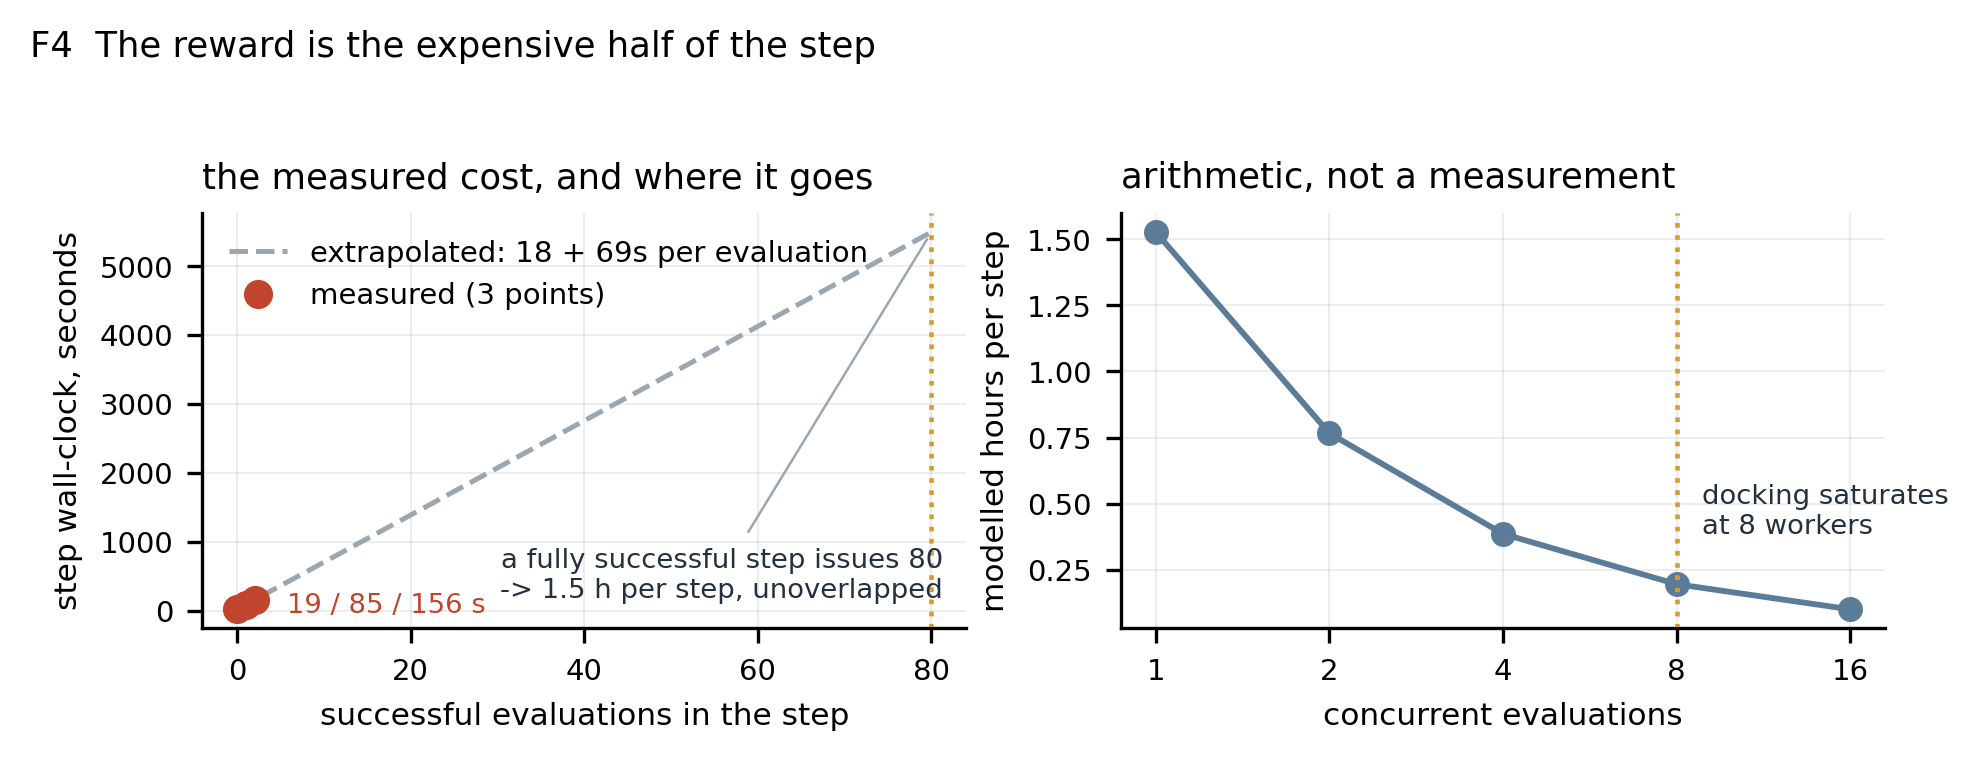

fit: 18.2s fixed + 68.5s per evaluation (the line's own estimate of a single GP call is 67s)
at 80 evaluations and 8-way concurrency: 12 min per step


In [6]:
gp = FACTS["gp_cost"]
obs = gp["step_seconds_observed"]
xs = np.array([0, 1, 2]); ys = np.array([obs["0_evals"], obs["1_eval"], obs["2_evals"]], float)
slope, intercept = np.polyfit(xs, ys, 1)
full = gp["gp_calls_per_step_all_success"]
grid = np.linspace(0, full, 200)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.6, 2.5))

a1.plot(grid, intercept + slope * grid, color=MUTE, lw=1.2, ls="--",
        label=f"extrapolated: {intercept:.0f} + {slope:.0f}s per evaluation")
a1.plot(xs, ys, "o", color=HL, ms=6, label="measured (3 points)")
a1.axvline(full, color=WARN, lw=1.1, ls=":")
a1.annotate(f"a fully successful step issues {full}\n"
            f"-> {(intercept + slope*full)/3600:.1f} h per step, unoverlapped",
            xy=(full, intercept + slope * full), xycoords="data",
            xytext=(0.97, 0.06), textcoords="axes fraction",
            ha="right", va="bottom", fontsize=6.6, color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTE, lw=.6))
a1.annotate("19 / 85 / 156 s", (1, ys[1]), textcoords="offset points",
            xytext=(10, -2), fontsize=6.6, color=HL)
a1.set_xlabel("successful evaluations in the step"); a1.set_ylabel("step wall-clock, seconds")
a1.set_title("the measured cost, and where it goes", loc="left")
a1.legend(frameon=False, loc="upper left")

conc = np.array([1, 2, 4, 8, 16])
hours = (intercept + slope * full / conc) / 3600
a2.plot(conc, hours, "o-", color=CTRL, lw=1.4, ms=5)
a2.axvline(8, color=WARN, lw=1.1, ls=":")
a2.annotate("docking saturates\nat 8 workers", (8, hours[3]), textcoords="offset points",
            xytext=(6, 12), fontsize=6.6, color=INK)
a2.set_xscale("log", base=2); a2.set_xticks(conc); a2.set_xticklabels(conc)
a2.set_xlabel("concurrent evaluations"); a2.set_ylabel("modelled hours per step")
a2.set_title("arithmetic, not a measurement", loc="left")
fig.suptitle("F4  The reward is the expensive half of the step",
             x=0.005, ha="left", fontsize=8.5)
fig.tight_layout(rect=(0, 0, 1, .94))
show(fig, "f4_gp_wall")

print(f"fit: {intercept:.1f}s fixed + {slope:.1f}s per evaluation "
      f"(the line's own estimate of a single GP call is {gp['seconds_per_gp_call_sk']:.0f}s)")
print(f"at {full} evaluations and 8-way concurrency: {(intercept + slope*full/8)/60:.0f} min per step")

**F4.** The three measured points fit a line at roughly 67 seconds per evaluation, which is the line's own independent estimate of a single GP call; everything to the right of them is arithmetic, not measurement. Under the synchronous trainer this sits on the critical path, which is the whole case for the fully async one, and phase item C4 is what turns that case into a number.

## 5. Which algorithm settings are worth trying first

f5_ablation.png  59 KB


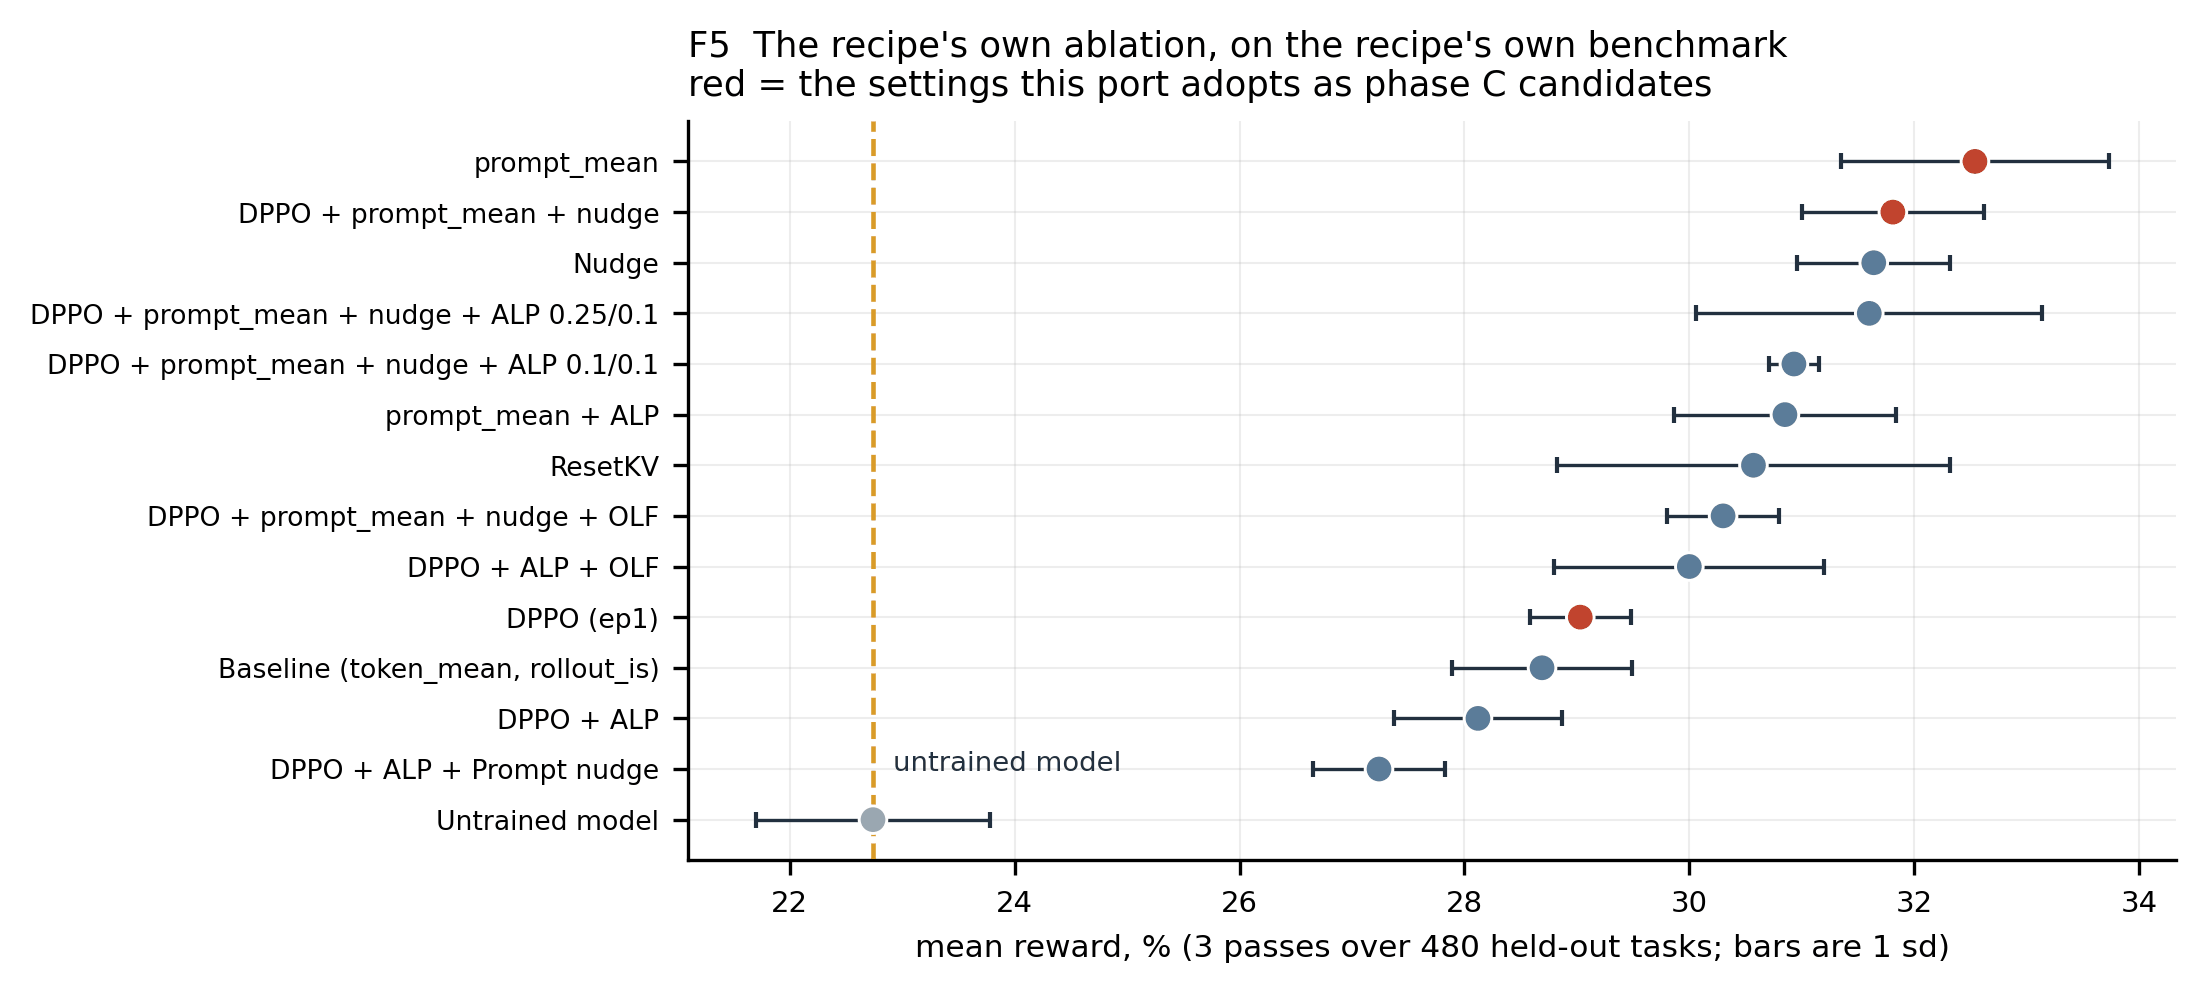

top row beats the untrained model by 9.80 points; the spread across the trained rows is 5.30, against a typical 1-sd bar of 0.81.
This is Qwen3.6-35B-A3B on knowledge-work tasks, not molecules: it ranks candidates, it does not transfer a result.


In [7]:
ab = FACTS["ablation"]["rows"]
labels = [r["run"] for r in ab][::-1]
vals = np.array([r["mean_reward"] for r in ab][::-1])
sds = np.array([r["sd"] for r in ab][::-1])
adopt = [r["adopt"] for r in ab][::-1]
base = next(r["mean_reward"] for r in ab if r["run"].startswith("Untrained"))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
y = np.arange(len(labels))
colors = [HL if a else (MUTE if l.startswith("Untrained") else CTRL)
          for a, l in zip(adopt, labels)]
ax.errorbar(vals, y, xerr=sds, fmt="none", ecolor=INK, elinewidth=.8, capsize=2)
ax.scatter(vals, y, s=44, c=colors, zorder=3, edgecolor="white", lw=.7)
ax.axvline(base, color=WARN, lw=1.1, ls="--")
ax.text(base + .18, 1.1, "untrained model", fontsize=6.6, color=INK,
        ha="left", va="center")
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=6.4)
ax.set_ylim(-.8, len(labels) - .2)
ax.set_xlabel("mean reward, % (3 passes over 480 held-out tasks; bars are 1 sd)")
ax.set_title("F5  The recipe's own ablation, on the recipe's own benchmark\n"
             "red = the settings this port adopts as phase C candidates", loc="left")
show(fig, "f5_ablation")

trained = [v for v, l in zip(vals, labels) if not l.startswith("Untrained")]
print(f"top row beats the untrained model by {vals[-1]-base:.2f} points; "
      f"the spread across the trained rows is {max(trained)-min(trained):.2f}, "
      f"against a typical 1-sd bar of {np.median(sds):.2f}.")
print("This is Qwen3.6-35B-A3B on knowledge-work tasks, not molecules: it ranks candidates, it does not transfer a result.")

**F5.** These are the recipe's results on the recipe's own benchmark: a 35B mixture-of-experts model on knowledge-work tasks, not a 9B model proposing molecules. The table is useful for ordering what to try, and it is not evidence about this domain. Phase C is where it becomes evidence or stops being interesting.

## 6. What can be done at the same time

Grouping work into phases is only useful if the grouping says something true
about what blocks what. The register below is a dependency graph, and the levels
are computed from it rather than asserted.

f6_phase_dag.png  59 KB


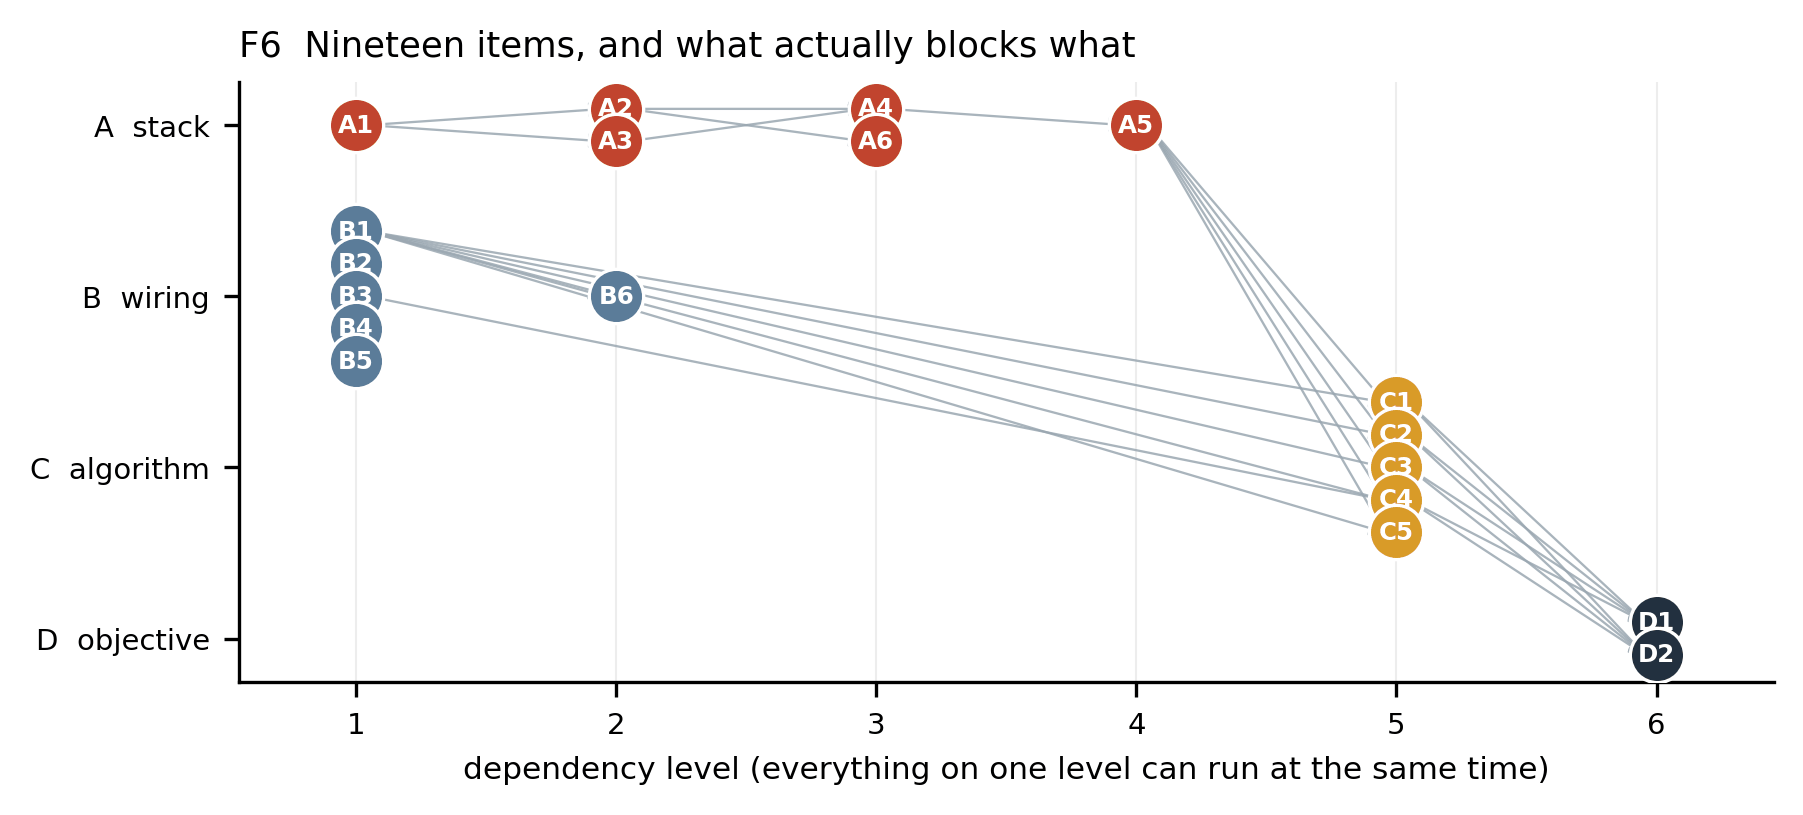

level 1: 6 items in parallel -> A1 B1 B2 B3 B4 B5
level 2: 3 items in parallel -> A2 A3 B6
level 3: 2 items in parallel -> A4 A6
level 4: 1 items in parallel -> A5
level 5: 5 items in parallel -> C1 C2 C3 C4 C5
level 6: 2 items in parallel -> D1 D2

phase B items that wait on phase A: none


In [8]:
items = {i["id"]: i for i in PHASES["items"]}
level = {}
def lvl(i):
    if i in level: return level[i]
    d = items[i]["deps"]
    level[i] = 1 + max((lvl(x) for x in d), default=0)
    return level[i]
for i in items: lvl(i)

phases = ["A", "B", "C", "D"]
prow = {p: k for k, p in enumerate(phases)}
pcol = {"A": HL, "B": CTRL, "C": WARN, "D": INK}
maxlvl = max(level.values())

fig, ax = plt.subplots(figsize=(6.6, 2.6))
pos = {}
for p in phases:
    ids = sorted((i for i in items if items[i]["phase"] == p), key=lambda i: (level[i], i))
    bylvl = {}
    for i in ids:
        bylvl.setdefault(level[i], []).append(i)
    for L, group in bylvl.items():
        for k, i in enumerate(group):
            pos[i] = (L, prow[p] + (k - (len(group) - 1) / 2) * 0.19)
for i, it in items.items():
    for d in it["deps"]:
        (x0, y0), (x1, y1) = pos[d], pos[i]
        ax.annotate("", xy=(x1 - .045, y1), xytext=(x0 + .045, y0),
                    arrowprops=dict(arrowstyle="-|>", color=MUTE, lw=.55,
                                    shrinkA=0, shrinkB=0, alpha=.85))
for i, (x, y) in pos.items():
    ax.scatter([x], [y], s=170, color=pcol[items[i]["phase"]], zorder=3, edgecolor="white", lw=.8)
    ax.text(x, y, i, ha="center", va="center", color="white", fontsize=5.9,
            fontweight="bold", zorder=4)
ax.set_yticks(list(prow.values()))
ax.set_yticklabels([f"{p}  {PHASES['items'][0]['phase'] and ''}" for p in phases])
ax.set_yticklabels(["A  stack", "B  wiring", "C  algorithm", "D  objective"])
ax.invert_yaxis()
ax.set_xticks(range(1, maxlvl + 1))
ax.set_xlabel("dependency level (everything on one level can run at the same time)")
ax.set_xlim(.55, maxlvl + .45); ax.grid(axis="y", alpha=0)
ax.set_title("F6  Nineteen items, and what actually blocks what", loc="left")
show(fig, "f6_phase_dag")

width = {}
for i in items: width.setdefault(level[i], []).append(i)
for L in sorted(width):
    print(f"level {L}: {len(width[L])} items in parallel -> {' '.join(sorted(width[L]))}")
b_deps_on_a = [i for i in items if items[i]["phase"] == "B"
               and any(items[d]["phase"] == "A" for d in items[i]["deps"])]
print(f"\nphase B items that wait on phase A: {b_deps_on_a or 'none'}")

**F6.** The result worth acting on: no phase-B item depends on any phase-A item. The entire domain-wiring phase is CPU-only and can be written and tested on a login node while phase A is still deciding whether the stack installs. Phase A is a chain rather than a fan-out, which is a property of the stack, not a scheduling choice.

## 7. Failure to mechanism to phase item

In [9]:
import pandas as pd
rows = [
 ("zero-variance groups make GRPO's (r-mean)/std into 0/0",
  "raise n_samples to 8, costing 4x the rollouts",
  "grpo_norm_by_std=false removes the division; zero_variance_filter masks the group",
  "C1, C2"),
 ("a GP call takes 67 s and a full step issues up to 80 of them",
  "none; the cost sits on the critical path of every step",
  "FullyAsyncRayPPOTrainer overlaps rollout with training; the rate limiter bounds concurrency",
  "C4, B3"),
 ("9B gradients for linear_attn.A_log and dt_bias are all non-finite",
  "seven hypotheses excluded by measurement; unresolved",
  "the recipe documents a same-family GDN backward failure with a named cause (the tilelang JIT missing CUDA headers)",
  "C5"),
 ("50 of 111 runs died to GPU memory taken by neighbours",
  "verify each card is empty before launching",
  "nothing: this is a scheduler-level problem and both lines have it equally",
  "unchanged"),
]
T = pd.DataFrame(rows, columns=["measured on the slime line", "what the slime line does",
                                "what SkyRL 0.3.0 offers", "phase items"])
display(T.style.hide(axis="index").set_properties(**{"text-align": "left", "font-size": "11px"}))

measured on the slime line,what the slime line does,what SkyRL 0.3.0 offers,phase items
zero-variance groups make GRPO's (r-mean)/std into 0/0,"raise n_samples to 8, costing 4x the rollouts",grpo_norm_by_std=false removes the division; zero_variance_filter masks the group,"C1, C2"
a GP call takes 67 s and a full step issues up to 80 of them,none; the cost sits on the critical path of every step,FullyAsyncRayPPOTrainer overlaps rollout with training; the rate limiter bounds concurrency,"C4, B3"
9B gradients for linear_attn.A_log and dt_bias are all non-finite,seven hypotheses excluded by measurement; unresolved,the recipe documents a same-family GDN backward failure with a named cause (the tilelang JIT missing CUDA headers),C5
50 of 111 runs died to GPU memory taken by neighbours,verify each card is empty before launching,nothing: this is a scheduler-level problem and both lines have it equally,unchanged


## 8. The register

Every item carries a criterion written down before the measurement, the artifact
it must leave behind, its budget, and its dependencies.

In [10]:
reg = pd.DataFrame([{"id": i["id"], "phase": i["phase"], "item": i["title"],
                     "criterion": i["criterion"], "budget": i["budget"],
                     "depends on": ", ".join(i["deps"]) or "-"}
                    for i in PHASES["items"]])
display(reg.style.hide(axis="index").set_properties(**{"text-align": "left", "font-size": "10px"}))

id,phase,item,criterion,budget,depends on
A1,A,uv resolve of the SkyRL 0.3.0 pin set on aarch64,"uv lock succeeds and the resolved torch is a +cu128 or +cu129 build (never +cu130, which makes torch.cuda.is_available() return False on driver 565)",CPU only,-
A2,A,vLLM 0.23.0+cu129 aarch64 wheel imports and serves,import vllm succeeds and a 0.8B model emits one token on one GH200,1 GPU x 30 min,A1
A3,A,Megatron backend initialises on one GPU,trainer.strategy=megatron reaches the first forward without raising; reuses the aarch64 Transformer Engine the slime line already built,1 GPU x 30 min,A1
A4,A,NCCL weight sync between Megatron and vLLM,after one sync the engine's output changes with the policy weights; identical output would mean the sync silently did nothing,1 GPU x 30 min,"A2, A3"
A5,A,"One-GPU colocated smoke, end to end, with a constant-reward generator","two training steps complete and a checkpoint is written, using a generator that contains no LDM code at all",1 GPU x 1 h,A4
A6,A,Which vLLM attention backend gets selected without flashinfer,"the backend name is printed and A2 still passes; the recipe pins flashinfer for x86_64 only, so aarch64 falls back to something unnamed",folded into A2,A2
B1,B,"LDMAcquisitionGenerator, the bridge.py replacement",one episode completes against an injected fake engine and fake env; every required GeneratorOutput key is present and the loss mask is 1 only on policy-generated tokens,CPU only,-
B2,B,EpisodeSpec JSONL to a SkyRL prompt dataset,the dataset length equals the JSONL line count and each row round-trips back to the same EpisodeSpec,CPU only,-
B3,B,Reward path as a Ray task behind the rate limiter,"concurrency never exceeds the configured bound; excess work queues rather than oversubscribing Vina, whose measured saturation point is 8 workers",CPU only,-
B4,B,Config dataclasses and the two entrypoints,--help lists the LDM-specific fields and the YAML defaults merge under CLI overrides,CPU only,-


## 9. Phase A, measured

A1, A2 and A6 have been run on this cluster. A3, A4 and A5 have not.

f7_phase_a.png  65 KB


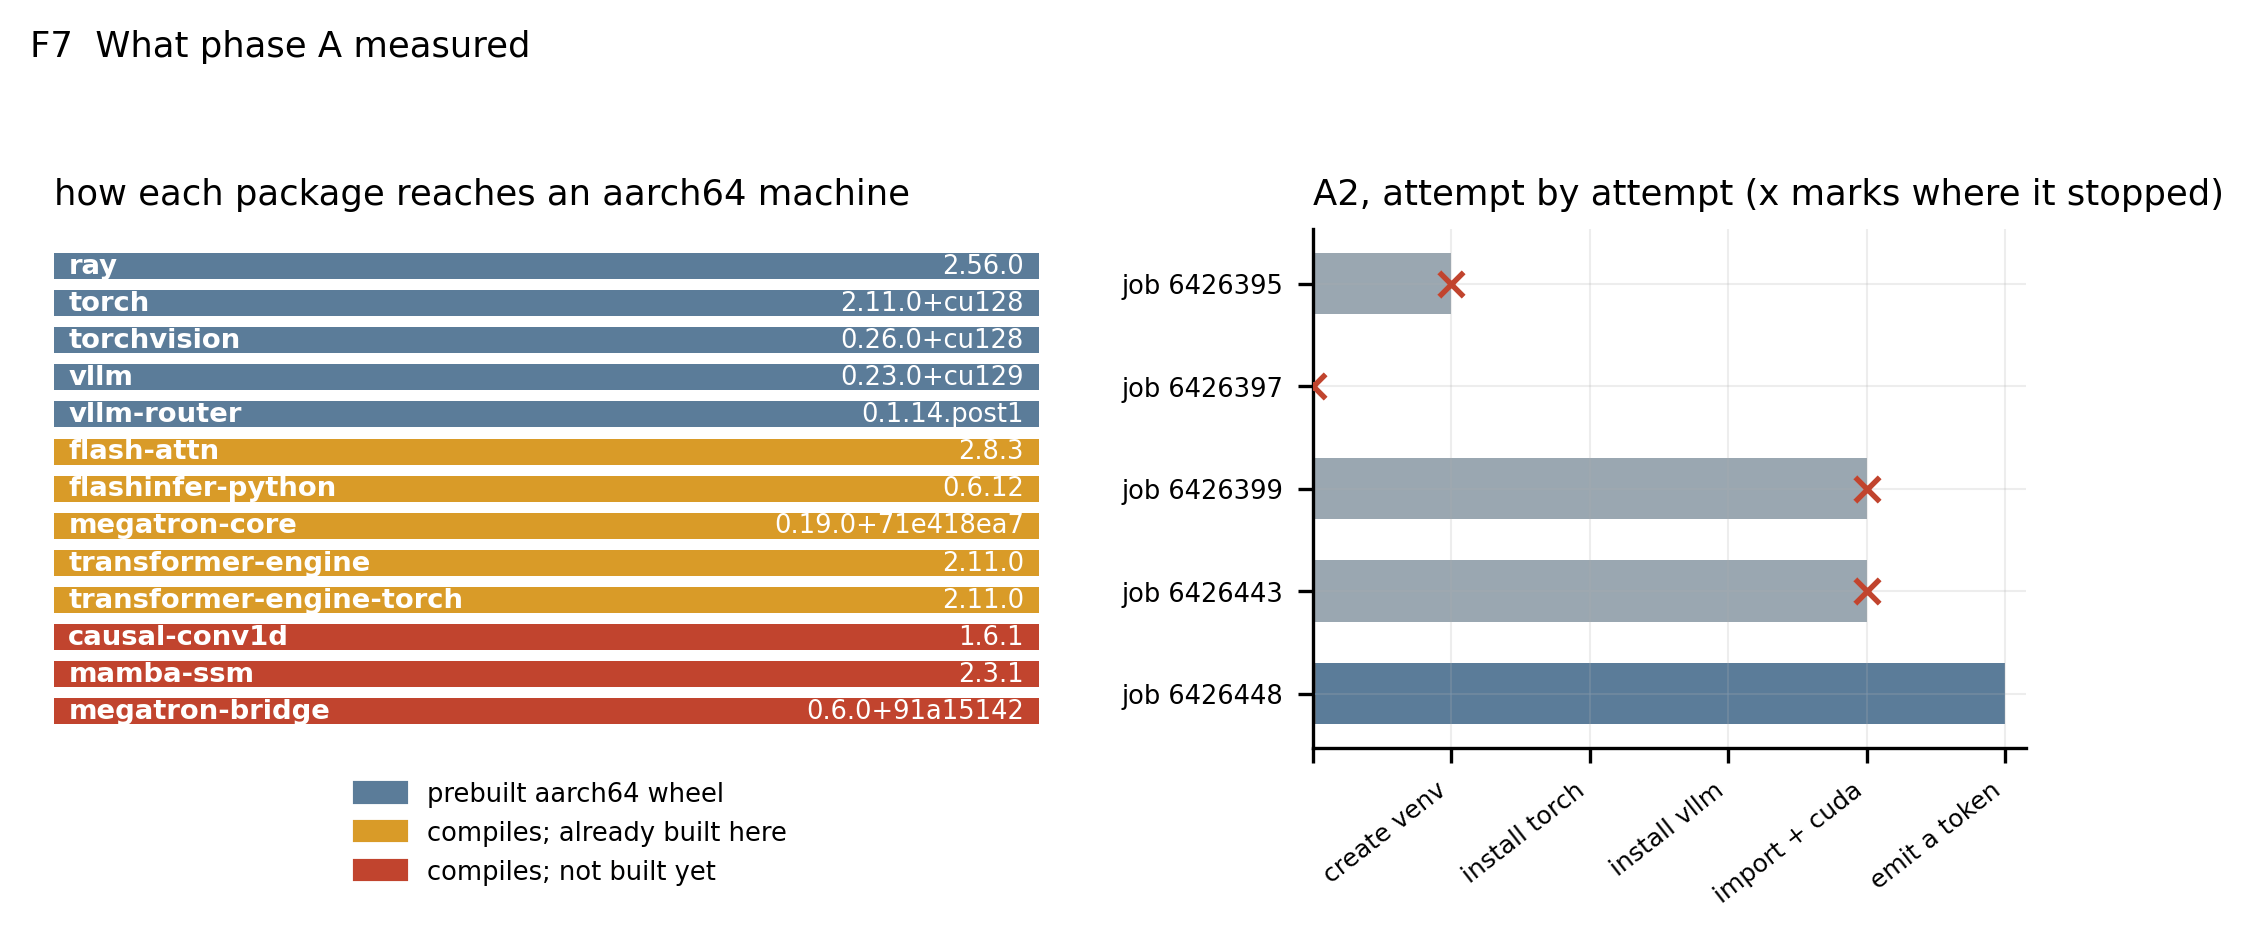

13 heavy packages: 5 arrive as aarch64 wheels, 5 would compile but are already built in /home/u6gb/kangli.u6gb/envs/ldm-rl-train, 3 are neither.
still to build: ['mamba-ssm', 'causal-conv1d', 'megatron-bridge']

  job 6426395  stopped at install torch
      uv index strategy is first-match: it found the torch NAME on PyPI and never looked at the pytorch index named one line above
  job 6426397  stopped at create venv
      the previous attempt left a valid empty venv behind; fixed with --allow-existing rather than by deleting it
  job 6426399  stopped at generate one token
      probe had no if __name__ == '__main__' guard, and vLLM v1 spawns its engine core, which re-imports the main module
  job 6426443  stopped at generate one token
      flashinfer JIT-compiles its sampling kernel at first use and found no CUDA toolkit; the only nvcc in the venv is a CUDA 13 one
  job 6426448  PASS


In [11]:
dl = PA["delivery"]
built = {k.replace("_", "-"): v for k, v in PA["already_built_here"]["versions"].items() if v}

def bucket(d):
    if "prebuilt" in d["delivery"]: return 0
    if d["package"] in built:       return 1
    return 2

rows = sorted(dl, key=lambda d: (bucket(d), d["package"]))
cols = [CTRL, WARN, HL]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.8, 3.1), gridspec_kw={"width_ratios": [1.45, 1]})

y = np.arange(len(rows))[::-1]
for yi, d in zip(y, rows):
    a1.barh(yi, 1, color=cols[bucket(d)], height=.7, edgecolor="none")
    a1.text(0.015, yi, d["package"], va="center", ha="left", color="white",
            fontsize=6.6, fontweight="bold")
    a1.text(0.985, yi, d["version"], va="center", ha="right", color="white", fontsize=6.2)
a1.set_yticks([]); a1.set_xticks([]); a1.grid(False)
for sp in a1.spines.values(): sp.set_visible(False)
a1.set_title("how each package reaches an aarch64 machine", loc="left")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in cols]
a1.legend(handles, ["prebuilt aarch64 wheel", "compiles; already built here", "compiles; not built yet"],
          loc="upper center", bbox_to_anchor=(.5, -.02), ncol=1, frameon=False, fontsize=6.2)

STAGES = ["create venv", "install torch", "install vllm", "import + cuda", "emit a token"]
smap = {"create venv": 0, "install torch": 1, "install vllm": 2, "generate one token": 4, "passed": 5}
att = PA["a2"]["attempts"]
ya = np.arange(len(att))[::-1]
for yi, a in zip(ya, att):
    reached = smap[a["stopped_at"]]
    ok = a["stopped_at"] == "passed"
    a2.barh(yi, reached, color=(CTRL if ok else MUTE), height=.6, edgecolor="none")
    if not ok:
        a2.scatter([reached], [yi], marker="x", s=34, color=HL, zorder=3, linewidths=1.3)
a2.set_yticks(ya); a2.set_yticklabels([f"job {a['job']}" for a in att], fontsize=6.2)
a2.set_xticks(range(len(STAGES) + 1)); a2.set_xticklabels([""] + STAGES, rotation=38, ha="right", fontsize=6.0)
a2.set_xlim(0, 5.15)
a2.set_title("A2, attempt by attempt (x marks where it stopped)", loc="left")
fig.suptitle("F7  What phase A measured", x=0.005, ha="left", fontsize=8.5)
fig.tight_layout(rect=(0, 0, 1, .93))
show(fig, "f7_phase_a")

n = [sum(1 for d in dl if bucket(d) == k) for k in range(3)]
print(f"{len(dl)} heavy packages: {n[0]} arrive as aarch64 wheels, {n[1]} would compile but are "
      f"already built in {PA['already_built_here']['env']}, {n[2]} are neither.")
print("still to build:", [d["package"] for d in dl if bucket(d) == 2])
print()
for a in att:
    print(f"  job {a['job']}  " + ("PASS" if a["stopped_at"] == "passed" else f"stopped at {a['stopped_at']}"))
    if a["cause"]: print(f"      {a['cause']}")

**F7.** The left panel is what moves phase A: of the packages with no prebuilt aarch64 wheel, most are already compiled here, because the slime line built them. The route is to add vLLM and SkyRL to that stack rather than install this lock from nothing. The right panel is A2's five attempts; all four failures were in the probe or the install command and none in the stack, and each stopped within minutes because the install forbids source builds.

In [12]:
a1r, a2r = PA["a1"], PA["a2"]
reg = pd.DataFrame([
 {"item": "A1", "criterion": a1r["criterion"], "result": a1r["status"],
  "evidence": f"{a1r['packages_resolved']} packages resolved; torch {a1r['torch_version']} "
              f"({a1r['torch_delivery']}); 'cu130' appears {a1r['cu130_occurrences']} times in the lock"},
 {"item": "A2", "criterion": "import vllm succeeds and a model emits one token on one GH200",
  "result": a2r["status"],
  "evidence": f"job {a2r['job_id']} on {a2r['node']}: torch {a2r['torch']}, vllm {a2r['vllm']}, "
              f"cuda available {a2r['cuda_available']}, {a2r['device']}; "
              f"model load {a2r['model_load']}; token emitted {a2r['token_text']}"},
 {"item": "A6", "criterion": "name the attention backend vLLM selects on aarch64", "result": "PASS",
  "evidence": f"{a2r['attention_backend']}, chosen out of {a2r['backend_candidates']}; "
              f"flashinfer {a2r['flashinfer']} -- it is not absent on aarch64"},
 {"item": "A3", "criterion": "trainer.strategy=megatron reaches the first forward", "result": "not run",
  "evidence": "next; should reuse the already-built stack rather than install from the lock"},
 {"item": "A4", "criterion": "engine output changes after one NCCL weight sync", "result": "not run", "evidence": ""},
 {"item": "A5", "criterion": "two training steps and a checkpoint, constant-reward generator", "result": "not run", "evidence": ""},
])
display(reg.style.hide(axis="index").set_properties(**{"text-align": "left", "font-size": "10px"}))

item,criterion,result,evidence
A1,uv lock succeeds and the resolved torch is a +cu128 or +cu129 build,PASS,322 packages resolved; torch 2.11.0+cu128 (prebuilt aarch64 wheel); 'cu130' appears 0 times in the lock
A2,import vllm succeeds and a model emits one token on one GH200,PASS,"job 6426448 on nid010771: torch 2.11.0+cu128, vllm 0.23.0+cu129, cuda available True, NVIDIA GH200 120GB; model load 2.98 GiB memory and 2.092806 seconds; token emitted ' Paris'"
A6,name the attention backend vLLM selects on aarch64,PASS,"FLASH_ATTN, chosen out of 'FLASH_ATTN', 'FLASHINFER', 'TRITON_ATTN', 'FLEX_ATTENTION'; flashinfer present -- it is not absent on aarch64"
A3,trainer.strategy=megatron reaches the first forward,not run,next; should reuse the already-built stack rather than install from the lock
A4,engine output changes after one NCCL weight sync,not run,
A5,"two training steps and a checkpoint, constant-reward generator",not run,


Two of the four A2 failures are worth keeping rather than tidying away, because
both are traps any later phase item can fall into.

`uv`'s index strategy is first-match: it stops at the first index carrying a
package *name*. `torch` exists on PyPI, so the pytorch index named one line
above was never consulted, and the error read "no version of
torch==2.11.0+cu128" while that wheel sat on that index. A name being present is
not a version being present.

flashinfer JIT-compiles its sampling kernel on first use, and the only `nvcc`
inside a fresh venv is `site-packages/nvidia/cu13/bin/nvcc` -- a CUDA 13
compiler, arriving as an ordinary dependency, on a cluster whose driver is CUDA
12.7. The recipe records the same shape of trap for tilelang's gated-delta-net
kernel. `CUDA_HOME` now points at the 12.9 toolkit the slime line already built
against. This one reaches past A2: a runtime JIT that quietly picks the cu13
compiler is the CUDA red line being crossed from inside an environment that
otherwise looks fine.

## 10. What this plan does not claim

The recipe records a gated-delta-net backward failure whose cause is named: the
TileLang JIT compiling the GDN kernels without a full CUDA toolkit, dying on a
missing `cuda/atomic` header. The 9B failure here is in the same family of
layers. That is a lead and not a diagnosis, and phase item C5 is written to ask
only whether the failure reproduces on the SkyRL stack. It is worth running
whichever way it lands: reproduction points at the model or the checkpoint,
while non-reproduction points at the training stack and gives the line back its
9B runs.

Nothing here proposes retiring slime. A1, A2 and A6 have run and are reported
above; A3, A4 and A5 have not, so nothing here says the training loop closes.
And the neighbour-contention failure that
killed 50 of 111 runs is untouched by any of this, because it is a property of
the scheduler rather than of the framework.